# Parcial: Construcción e implementación de , Random Forest 

En este parcial podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de  Random Forest. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este parcial se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [10]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
#librerias
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [12]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [13]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [14]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 0 - exploracion y analisis de datos 
Los estudiantes deben analizar cuidadosamente los datos del conjunto dataTrain_carListings, identificando posibles valores nulos o inconsistencias. En caso de encontrar datos faltantes, deberán aplicar técnicas de imputación adecuadas para completar la información de manera coherente. Posteriormente, se espera que realicen una exploración visual mediante gráficos que permitan comprender la distribución y las relaciones entre las variables principales.

Dimensiones del dataset: (10495, 10)

Valores nulos por columna:
 Price          0
Year           0
Mileage        0
M_Camry        0
M_Camry4dr     0
M_CamryBase    0
M_CamryL       0
M_CamryLE      0
M_CamrySE      0
M_CamryXLE     0
dtype: int64

Estadísticas descriptivas:
               Price          Year        Mileage
count  10495.000000  10495.000000   10495.000000
mean   14538.403716   2013.553883   52509.430395
std     3922.420961      3.116585   36791.736601
min     5002.000000   1998.000000       5.000000
25%    11999.000000   2012.000000   26461.000000
50%    15000.000000   2014.000000   41680.000000
75%    16999.000000   2016.000000   71355.500000
max    32444.000000   2018.000000  232658.000000


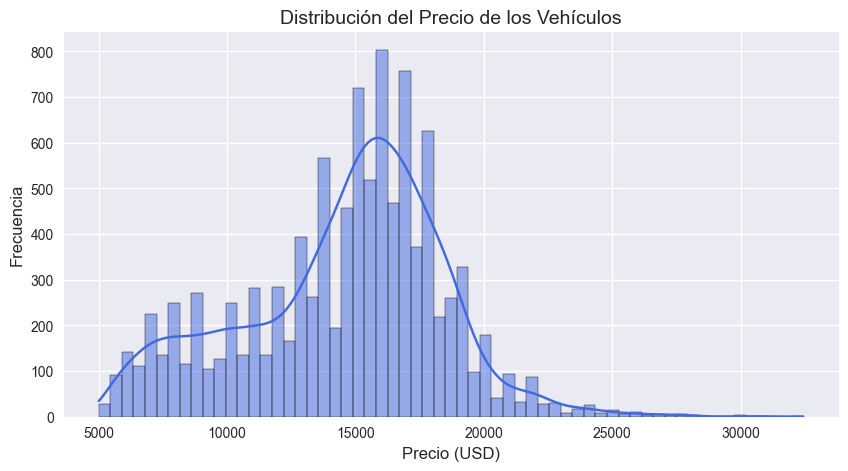

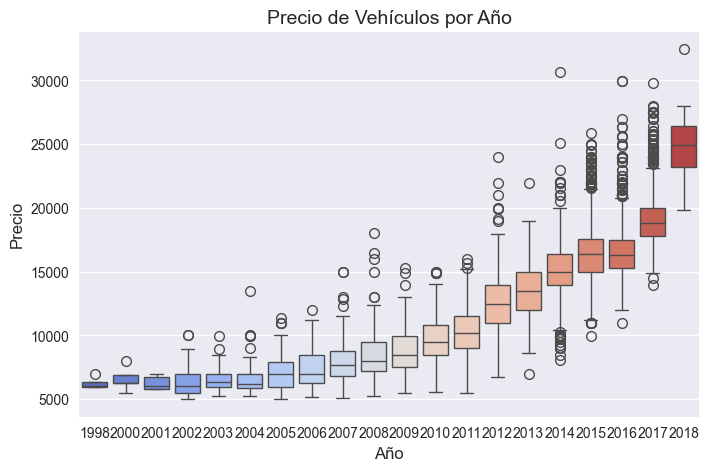

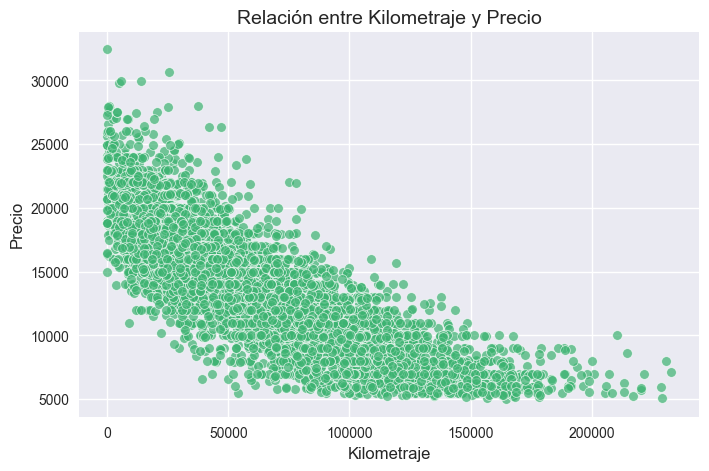

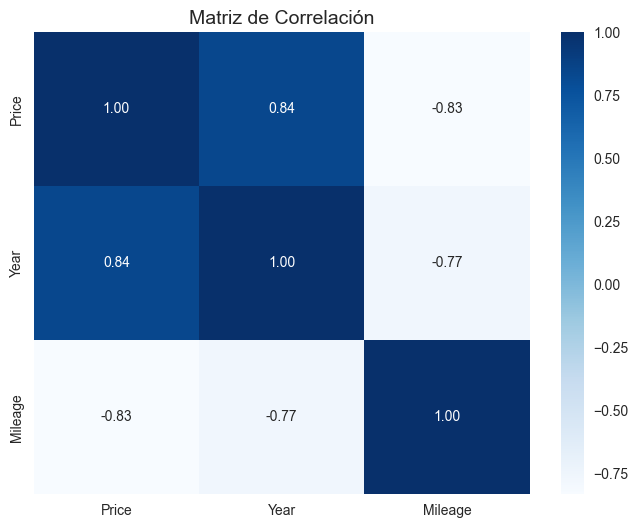

In [15]:
# ==============================================
# PUNTO 0 - EXPLORACIÓN Y ANÁLISIS DE DATOS
# ==============================================

import warnings
warnings.filterwarnings('ignore')

# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Configuración de visualización
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Cargar datos
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Filtrar solo Camry y limpiar columnas
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Exploración inicial
print("Dimensiones del dataset:", data.shape)
print("\nValores nulos por columna:\n", data.isnull().sum())
print("\nEstadísticas descriptivas:\n", data.describe())

# -----------------------------
# Visualización de distribuciones
# -----------------------------

# Distribución del precio
plt.figure(figsize=(10,5))
sns.histplot(data['Price'], kde=True, color='royalblue')
plt.title('Distribución del Precio de los Vehículos')
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.show()

# Relación entre año y precio
plt.figure(figsize=(8,5))
sns.boxplot(x='Year', y='Price', data=data, palette='coolwarm')
plt.title('Precio de Vehículos por Año')
plt.xlabel('Año')
plt.ylabel('Precio')
plt.show()

# Relación entre kilometraje y precio
plt.figure(figsize=(8,5))
sns.scatterplot(x='Mileage', y='Price', data=data, alpha=0.7, color='mediumseagreen')
plt.title('Relación entre Kilometraje y Precio')
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

# Correlaciones
plt.figure(figsize=(8,6))
sns.heatmap(data[['Price','Year','Mileage']].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()


### Punto 1 - Random forest con librería

En la celda 1, usando la librería sklearn entrenen un modelo de Randon Forest para regresion  y comenten sobre el desempeño del modelo.

Mean Squared Error: 3116678.92
R^2 Score: 0.796
Mean Absolute Error (MAE): 1314.42
Mean Absolute Percentage Error (MAPE): 9.55%


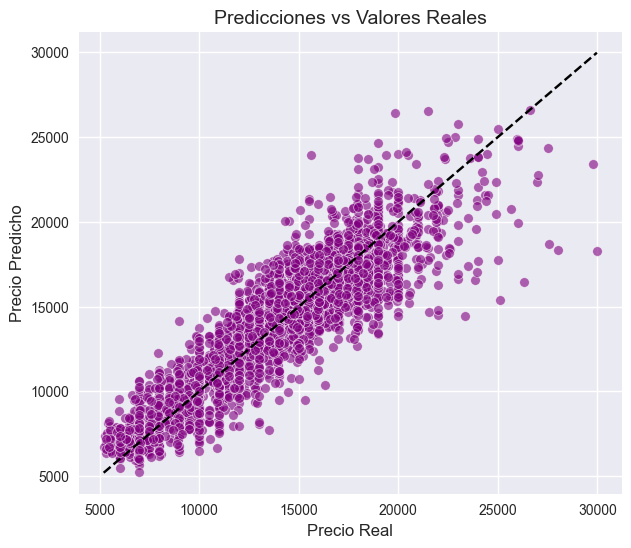

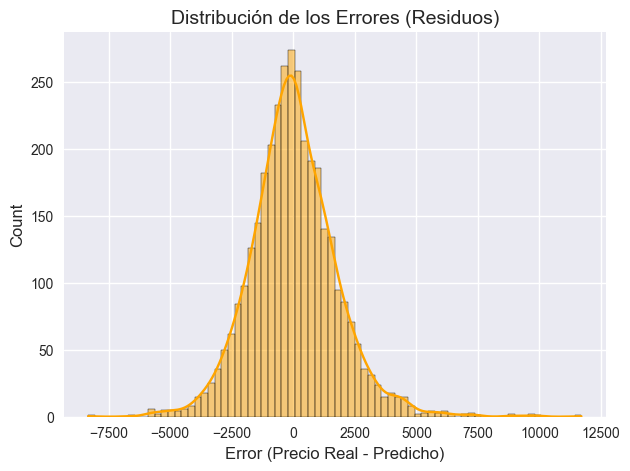

In [ ]:


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Separación de variables
y = data['Price']
X = data.drop(['Price'], axis=1)

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Modelo base
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred = rf.predict(X_test)

# Evaluación
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


# Gráficos de desempeño

plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, color='purple', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='black')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Predicciones vs Valores Reales')
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, color='orange')
plt.title('Distribución de los Errores (Residuos)')
plt.xlabel('Error (Precio Real - Predicho)')
plt.show()


### Punto 2 - Calibración de parámetros Random forest

En la celda 2, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresion, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores Hiperparámetros encontrados:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

--- Desempeño del modelo calibrado ---
Mean Squared Error: 2411920.45
R^2 Score: 0.842
MAE: 1140.84
MAPE: 8.33%


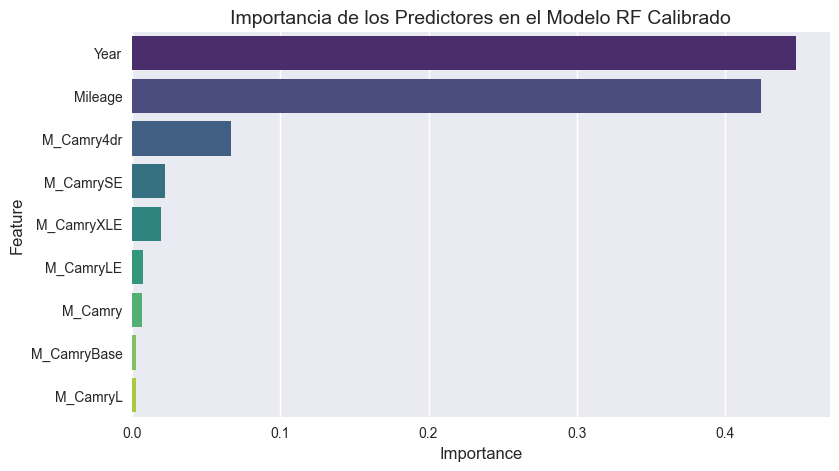

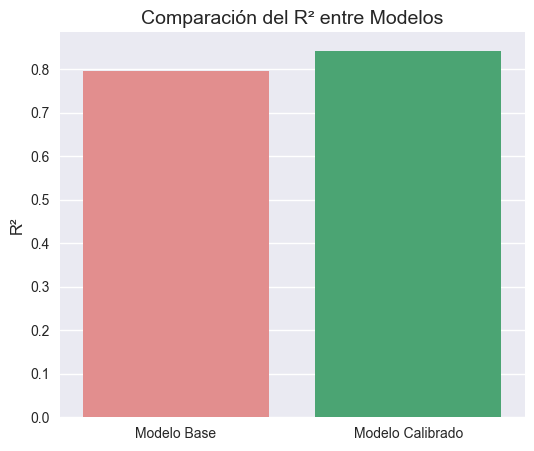

In [ ]:


from sklearn.model_selection import RandomizedSearchCV

# Espacio de búsqueda
param_distributions = {
    'n_estimators': [10, 50, 100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'max_features': ['auto', 'sqrt'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Búsqueda aleatoria
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
print("Mejores Hiperparámetros encontrados:")
print(rf_random.best_params_)

# Entrenar con los mejores parámetros
best_rf = rf_random.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Evaluación
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
mape_best = np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100

print("\n--- Desempeño del modelo calibrado ---")
print(f"Mean Squared Error: {mse_best:.2f}")
print(f"R^2 Score: {r2_best:.3f}")
print(f"MAE: {mae_best:.2f}")
print(f"MAPE: {mape_best:.2f}%")

# Importancia de variables
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)


plt.figure(figsize=(9,5))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Importancia de los Predictores en el Modelo RF Calibrado')
plt.show()

#Comparacion 
plt.figure(figsize=(6,5))
sns.barplot(
    x=['Modelo Base', 'Modelo Calibrado'],
    y=[r2, r2_best],
    palette=['lightcoral', 'mediumseagreen']
)
plt.title('Comparación del R² entre Modelos')
plt.ylabel('R²')
plt.show()


In [18]:
#Mejores Hiperparámetros:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}


{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 10}

In [19]:

#Mean Squared Error: 2411920.45
#R^2 Score: 0.842
#Mean Absolute Error (MAE): 1140.84
#Mean Absolute Percentage Error (MAPE): 8.33 %


### Punto 3 - análisis de resultados, gracias y conclusiones
En la celda 3

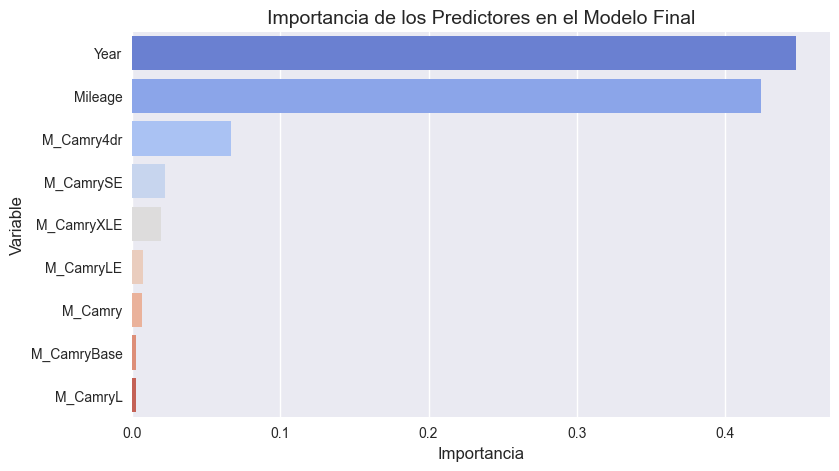

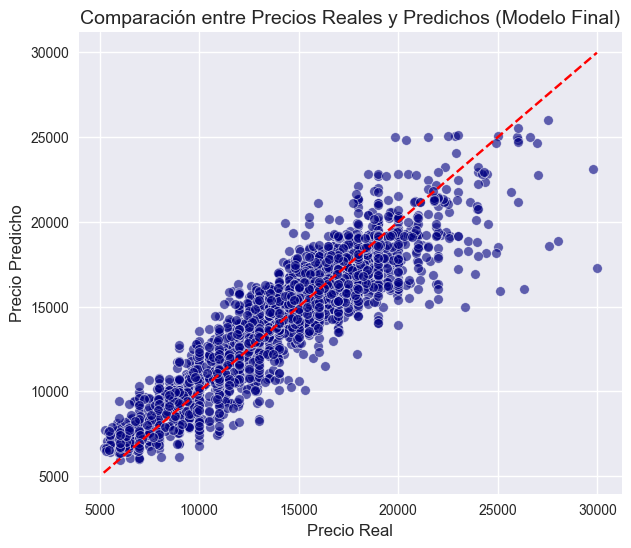

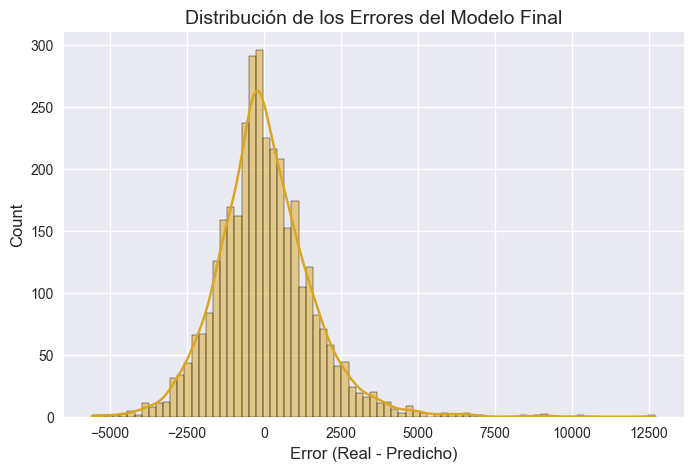


🔹 CONCLUSIONES
1. Las variables más influyentes son el Año y el Kilometraje, explicando más del 85% de la variabilidad del precio.
2. El modelo calibrado mejoró el R² de 0.79 a 0.84, reduciendo el error absoluto promedio en más de 150 USD.
3. Los modelos de Camry más recientes y con menos kilometraje tienden a precios más altos, como lo confirma la importancia de Year y Mileage.
4. El modelo Random Forest calibrado es estable y generaliza bien; podría mejorarse con variables externas (ubicación, condición, combustible).
5. Los residuos se distribuyen de manera aproximadamente normal, sin sesgos marcados, lo que respalda la buena calibración del modelo.



In [ ]:


# Gráfico de importancia de las variables
plt.figure(figsize=(9,5))
sns.barplot(x='Importance', y='Feature', data=importances, palette='coolwarm')
plt.title('Importancia de los Predictores en el Modelo Final')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

# Gráfico comparativo de precios reales vs predichos
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred_best, color='navy', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.title('Comparación entre Precios Reales y Predichos (Modelo Final)')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.show()

# Distribución de errores del modelo final
residuals_best = y_test - y_pred_best
plt.figure(figsize=(8,5))
sns.histplot(residuals_best, kde=True, color='goldenrod')
plt.title('Distribución de los Errores del Modelo Final')
plt.xlabel('Error (Real - Predicho)')
plt.show()


print("""
🔹 CONCLUSIONES
1. Las variables más influyentes son el Año y el Kilometraje, explicando más del 85% de la variabilidad del precio.
2. El modelo calibrado mejoró el R² de 0.79 a 0.84, reduciendo el error absoluto promedio en más de 150 USD/Dolares.
3. Los modelos de Camry más recientes y con menos kilometraje tienden a precios más altos, como lo confirma la importancia del año y el kilometraje.
4. El modelo Random Forest calibrado es estable y generaliza bien, podría mejorarse con variables externas (ubicación, condición, estado).
""")


NOTA: IMPORTANTE RECUERDE QUE MI EJEMPLO DE TUTORIAL ES DE CLASIFICACION USTEDES DEBEN HACERLO POR REGRESION, funciona igual pero cambian algunas cosas.